In [1]:
import numpy as np
import networkx as nx
import pickle
from matplotlib import pyplot as plt
from matplotlib.patches import Wedge, Patch
import json
import os
from collections import defaultdict
import pandas as pd

# Dependencies
* DDBC
* important_terms_analysis
* Clustering_Result_Analysis

# Loading

In [2]:
graph_dir = "../../Graphs"

In [3]:
# DISEASE_list = ['BIPOLAR', 'SCHIZOPHRENIA', 'LEUKEMIA', 'PARKINSON', 'DIABETES', 'BREASTCANCER',"NONE"]
DISEASE_list = ['BIPOLAR','SCHIZOPHRENIA', 'LEUKEMIA', 'BREASTCANCER',"NONE"]

In [4]:
disease_to_comm_dgidb_gene_count = {}

In [5]:
for disease in DISEASE_list:
    with open(f"../output/{disease}/comm_dgidb_gene_count.json", "r") as f:
        disease_to_comm_dgidb_gene_count[disease] = json.load(f)

In [6]:
def community_similarity_matrix(G, communities, normalize=True):
    """
    Compute community–community similarity as specified by PI:
        sim[i, j] = (sum of edge weights between members of communities i and j)
                    / (|Ci| * |Cj|)

    Then:
      - diagonal is forced to 0
      - matrix is normalized so that max(sim) = 1 (if normalize=True)
    """
    n = len(communities)
    sim = np.zeros((n, n), dtype=float)

    # ----- compute similarities -----
    for i in range(n):
        A = communities[i]
        sizeA = len(A)
        for j in range(i + 1, n):
            B = communities[j]
            sizeB = len(B)

            total_weight = 0.0
            for u in A:
                for v in B:
                    if G.has_edge(u, v):
                        total_weight += G[u][v].get("weight")

            value = total_weight / (sizeA * sizeB)
            sim[i, j] = value
            sim[j, i] = value

    # ----- set diagonal to zero -----
    np.fill_diagonal(sim, 0.0)

    # ----- normalization -----
    if normalize:
        max_val = sim.max()
        if max_val > 0:
            sim = sim / max_val
        # if max_val == 0 → leave as all zeros

    return sim


In [7]:
sims = []
cat_dicts = []
sizes_list = []  # or None per plot
num_dgidb_genes_dict= []
percentage_involved_dict = []
for disease in DISEASE_list:
    disease_FOLDER = f"../output/{disease}/"
    with open(f"{disease_FOLDER}/result_communities_selected.pkl", "rb") as f:
        communities_selected = pickle.load(f)
    with open(f"{disease_FOLDER}/result_graph.pkl", "rb") as f:
        graph = pickle.load(f)
    with open(f"{disease_FOLDER}/category_count_by_comm.pkl", "rb") as f:
        category_count_by_comm = pickle.load(f)
    with open(f"{disease_FOLDER}/comm_to_involved_pct.json", "rb") as f:
        percentage_involved = json.load(f)
    comm_sim_mat = community_similarity_matrix(graph, communities_selected, normalize = True)
    sizes = [len(c) for c in communities_selected]
    
    sims.append(comm_sim_mat)  
    cat_dicts.append(category_count_by_comm)  
    sizes_list.append(dict(enumerate(sizes))) 
    num_dgidb_genes = {int(k): v for k, v in disease_to_comm_dgidb_gene_count[disease].items()}
    num_dgidb_genes_dict.append(num_dgidb_genes)
    percentage_involved = {int(k): v for k, v in percentage_involved.items()}
    percentage_involved_dict.append(percentage_involved)

# Label table

In [8]:
# d is your big dict
num_terms_per_comm = {
    comm: sum(count for count, _ in cat_dict.values())
    for comm, cat_dict in cat_dicts[0].items()
}

num_terms_per_comm


{1: 109,
 2: 24,
 3: 203,
 4: 137,
 5: 654,
 6: 235,
 7: 49,
 8: 136,
 10: 9,
 11: 41,
 0: 0,
 9: 0}

In [9]:
percentage_involved_dict

[{0: 0.0,
  1: 0.5712900096993211,
  2: 0.3266596417281349,
  3: 0.512489233419466,
  4: 0.80927291886196,
  5: 0.955794504181601,
  6: 0.6832669322709163,
  7: 0.5274336283185841,
  8: 0.5351351351351351,
  9: 0.0,
  10: 1.0,
  11: 0.4406779661016949},
 {0: 0.0,
  1: 0.583,
  2: 0.3491062039957939,
  3: 0.5134665508253693,
  4: 0.9489274770173647,
  5: 0.9337016574585635,
  6: 0.3730994152046784,
  7: 0.5273722627737226,
  8: 0.6115107913669064,
  9: 0.0,
  10: 1.0,
  11: 0.48031496062992124},
 {0: 0.3264887063655031,
  1: 0.768102658111824,
  2: 0.02043132803632236,
  3: 0.40365984930032295,
  4: 0.5259678942398489,
  5: 0.9522842639593908,
  6: 0.6989247311827957,
  7: 0.548828125,
  8: 0.5508849557522124,
  9: 0.0,
  10: 1.0,
  11: 0.14634146341463414},
 {0: 0.3005893909626719,
  1: 0.23738532110091742,
  2: 0.6220806794055201,
  3: 0.5104347826086957,
  4: 0.8721047331319235,
  5: 0.9565217391304348,
  6: 0.352803738317757,
  7: 0.56353591160221,
  8: 0.6049382716049383,
  9: 0.0,

In [10]:
num_dgidb_genes_dict

[{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 266},
 {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 249},
 {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 198},
 {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 377},
 {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0}]

In [11]:
sizes_list

[{0: 1008,
  1: 1031,
  2: 949,
  3: 1162,
  4: 949,
  5: 837,
  6: 502,
  7: 565,
  8: 556,
  9: 340,
  10: 299,
  11: 119},
 {0: 863,
  1: 1000,
  2: 951,
  3: 1152,
  4: 979,
  5: 905,
  6: 859,
  7: 548,
  8: 417,
  9: 336,
  10: 300,
  11: 127},
 {0: 974,
  1: 1092,
  2: 884,
  3: 929,
  4: 1060,
  5: 985,
  6: 837,
  7: 512,
  8: 453,
  9: 342,
  10: 300,
  11: 123},
 {0: 1018,
  1: 872,
  2: 942,
  3: 1151,
  4: 993,
  5: 966,
  6: 860,
  7: 543,
  8: 406,
  9: 342,
  10: 298,
  11: 183},
 {0: 1025,
  1: 983,
  2: 1201,
  3: 1035,
  4: 1111,
  5: 748,
  6: 666,
  7: 534,
  8: 485,
  9: 342,
  10: 300}]

In [27]:
comm_stat_list = {}
for i in range(len(DISEASE_list)):
    comm_stat = {
        "percentage_involved": percentage_involved_dict[i],
        "size": sizes_list[i],
        "num_dgidb_genes": num_dgidb_genes_dict[i],
        "num_terms": num_terms_per_comm
    }
    comm_stat_list[DISEASE_list[i]] = comm_stat
    with open(f"{graph_dir}/{DISEASE_list[i]}/comm_stat.json", "w") as f:
        json.dump(comm_stat, f, indent=4)

In [13]:
for comm_stat in comm_stat_list.values():
    percentage_printable = {
        k: (f"{float(v) * 100:.2f}".rstrip("0").rstrip(".") if v is not None else "")
        for k, v in comm_stat["percentage_involved"].items()
    }
    print(percentage_printable)

{0: '0', 1: '57.13', 2: '32.67', 3: '51.25', 4: '80.93', 5: '95.58', 6: '68.33', 7: '52.74', 8: '53.51', 9: '0', 10: '100', 11: '44.07'}
{0: '0', 1: '58.3', 2: '34.91', 3: '51.35', 4: '94.89', 5: '93.37', 6: '37.31', 7: '52.74', 8: '61.15', 9: '0', 10: '100', 11: '48.03'}
{0: '32.65', 1: '76.81', 2: '2.04', 3: '40.37', 4: '52.6', 5: '95.23', 6: '69.89', 7: '54.88', 8: '55.09', 9: '0', 10: '100', 11: '14.63'}
{0: '30.06', 1: '23.74', 2: '62.21', 3: '51.04', 4: '87.21', 5: '95.65', 6: '35.28', 7: '56.35', 8: '60.49', 9: '0', 10: '100', 11: '33.88'}
{0: '22.73', 1: '0', 2: '49.5', 3: '74.95', 4: '94.69', 5: '45.45', 6: '93.09', 7: '56.74', 8: '56.61', 9: '0', 10: '100'}


# Graphing

In [14]:
def plot_community_graph_circular(
    sim_matrix,
    category_count_by_comm,
    major,                 # NEW: global major categories list (sorted)
    color_map,             # NEW: global color map dict: cat -> color
    threshold=0.0,
    community_sizes=None,
    figsize=(7, 7),
    edge_label_digits=2,
    pct_threshold=0.15,
    show_legend=False,     # NEW: default off (so you can have one global legend elsewhere)
    ax=None,               # NEW: allow drawing on a provided axis
    save_path=None,        # NEW: optional save path
):
    sim = np.asarray(sim_matrix)
    n = sim.shape[0]

    # ---- Graph ----
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            w = float(sim[i, j])
            if w > threshold:
                G.add_edge(i, j, weight=w)

    pos = nx.circular_layout(G)

    # ---- Radii ----
    if community_sizes is None:
        radii = np.full(n, 0.08)
    else:
        cs = np.maximum(np.asarray(list(community_sizes.values()), float), 0)
        radii = (0.06 + 0.10 * (cs / cs.max())) if cs.max() > 0 else np.full(n, 0.08)

    other_color = "lightgray"

    # ---- Plot ----
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        created_fig = True
    else:
        fig = ax.figure

    edge_w = nx.get_edge_attributes(G, "weight")
    if edge_w:
        nx.draw_networkx_edges(G, pos, width=[4 * w for w in edge_w.values()], alpha=0.8, ax=ax)
        nx.draw_networkx_edge_labels(
            G,
            pos,
            edge_labels={e: f"{w:.{edge_label_digits}f}" for e, w in edge_w.items()},
            font_size=8,
            label_pos=0.5,
            ax=ax,
        )

    used_other = False

    def fallback_node(x, y, r, node, face, hatch=None):
        ax.add_patch(plt.Circle((x, y), r, facecolor=face, edgecolor="black", hatch=hatch, linewidth=1.0))
        ax.text(x, y, str(node), ha="center", va="center", fontsize=12, weight="bold")

    for node in G.nodes():
        x, y = pos[node]
        r = radii[node]
        d = category_count_by_comm.get(node, {})

        num_terms = sum(c for c, _ in d.values() if c > 0)
        comm_size = community_sizes[node] if (community_sizes is not None and node < len(community_sizes)) else None

        total_here = sum(c for c, _ in d.values() if c > 0) if d else 0

        cats, counts = [], []
        other_count = 0
        for cat, (c, _) in d.items():
            if c <= 0:
                continue
            # SAME rule as before, but using provided global `major`
            if (c / total_here) >= pct_threshold and cat in major:
                cats.append(cat)
                counts.append(c)
            else:
                other_count += c

        if other_count > 0:
            cats.append("Other")
            counts.append(other_count)
            used_other = True

        total = float(sum(counts))
        if total <= 0:
            fallback_node(x, y, r, node, face="lightgray")
            continue

        start = 90.0
        for cat, c in zip(cats, counts):
            ang = 360.0 * (c / total)
            fc = other_color if cat == "Other" else color_map.get(cat, other_color)
            ax.add_patch(Wedge((x, y), r, start, start + ang, facecolor=fc, edgecolor="black", linewidth=0.5))
            start += ang

        ax.text(x, y, str(node), ha="center", va="center", fontsize=12, weight="bold")

    # ---- Legend (optional) ----
    if show_legend:
        patches = [Patch(facecolor=color_map[c], edgecolor="black", label=c) for c in major]
        if used_other:
            patches.append(Patch(facecolor=other_color, edgecolor="black", label="Other"))
        if patches:
            ax.legend(
                handles=patches,
                bbox_to_anchor=(1.2, 1),
                loc="upper left",
                borderaxespad=0.0,
                fontsize=8,
                title="Categories",
            )

    ax.set_aspect("equal", adjustable="box")  # ADDED: force circular nodes to remain circular
    ax.set_xlim(-1.25, 1.25)                  # ADDED: fixed x-range for circular layout
    ax.set_ylim(-1.25, 1.25)                  # ADDED: fixed y-range for circular layout
    ax.set_axis_off()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    if created_fig:
        plt.show()

    # Return whether "Other" appeared, so caller can decide if legend should include it
    return used_other


In [15]:
pct_threshold = 0.03

In [16]:
def compute_global_major(cat_dicts, pct_threshold=0.15):
    major = set()
    for category_count_by_comm in cat_dicts:
        for d in category_count_by_comm.values():
            total = sum(c for c, _ in d.values() if c > 0)
            if total <= 0:
                continue
            for cat, (c, _) in d.items():
                if c > 0 and (c / total) >= pct_threshold:
                    major.add(cat)
    return sorted(major)

major = compute_global_major(cat_dicts, pct_threshold=pct_threshold)
print("Global major categories:", len(major))

Global major categories: 42


In [17]:
combined = list(plt.get_cmap("tab20b").colors) + list(plt.get_cmap("tab20c").colors)
color_map = {cat: combined[i % len(combined)] for i, cat in enumerate(major)}


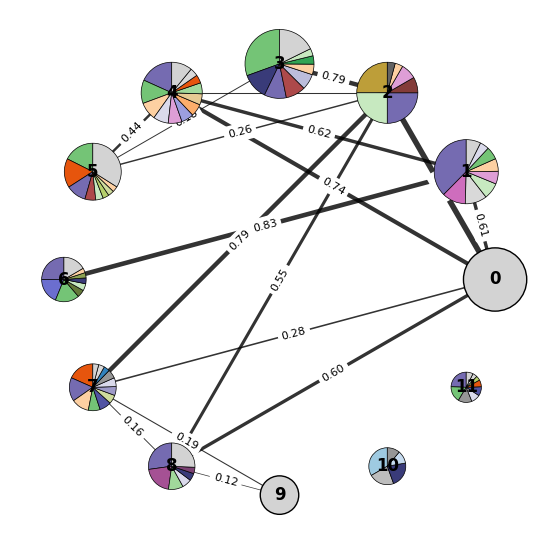

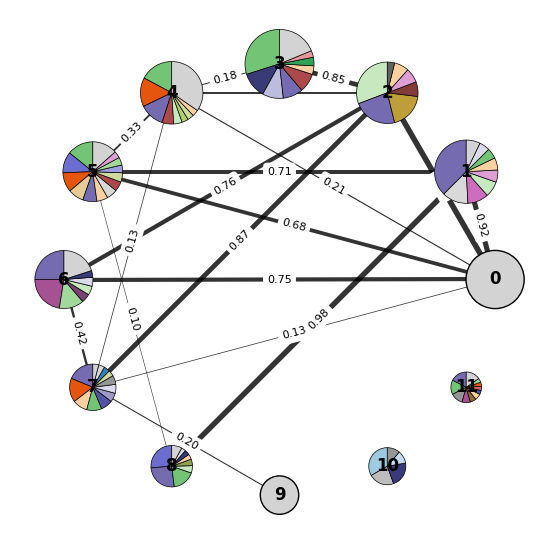

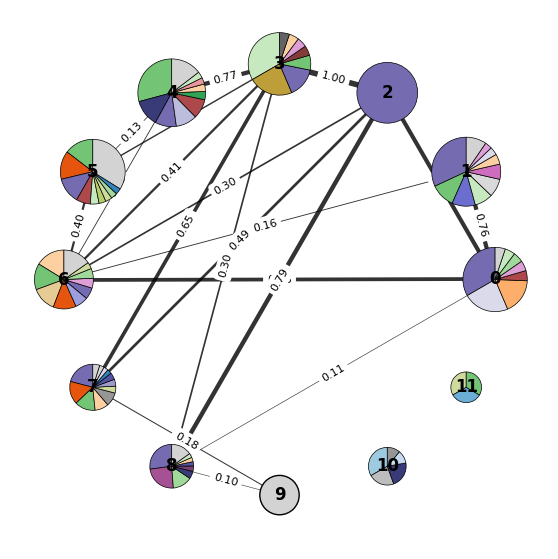

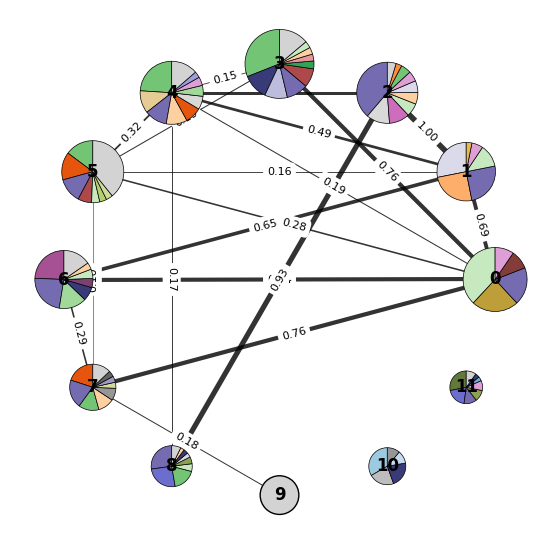

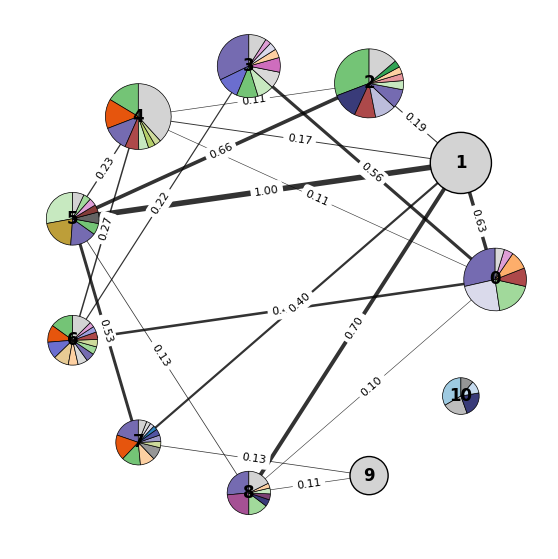

Saved plots to: ../../Graphs


In [18]:
used_other_any = False
for (disease, sim, cat_by_comm, sizes, num_dgidb_genes, pcts) in zip(DISEASE_list, sims, cat_dicts, sizes_list, num_dgidb_genes_dict,percentage_involved_dict):
    used_other = plot_community_graph_circular(
        sim_matrix=sim,
        category_count_by_comm=cat_by_comm,
        major=major,
        color_map=color_map,
        threshold=0.1,
        community_sizes=sizes,
        pct_threshold=pct_threshold,
        show_legend=False,
        save_path= f"{graph_dir}/{disease}/community_detection_result.pdf"
    )
    used_other_any = used_other_any or used_other

print("Saved plots to:", graph_dir)


# Create legend

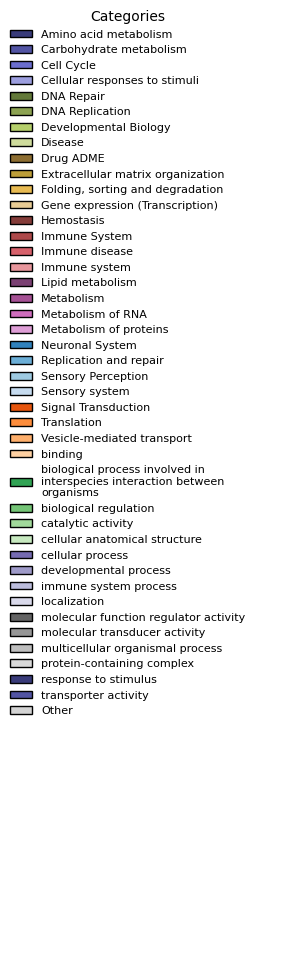

In [19]:
import textwrap  # changed: wrap long legend labels

other_color = "lightgray"

wrap_width = 40  # changed: adjust this number to control where labels wrap

patches = [
    Patch(
        facecolor=color_map[c],
        edgecolor="black",
        label=textwrap.fill(c, width=wrap_width)  # changed: wrap long category names
    )
    for c in major
]

if used_other_any:
    patches.append(
        Patch(
            facecolor=other_color,
            edgecolor="black",
            label="Other"
        )
    )

legend_fig = plt.figure(figsize=(3, 0.25 * len(patches)))
legend_fig.legend(
    handles=patches,
    loc="upper left",
    fontsize=8,
    title="Categories",
    frameon=False,
)
plt.axis("off")
legend_fig.savefig(f"{graph_dir}/legend.pdf", bbox_inches="tight", pad_inches=0.02)

In [20]:
graph_dir

'../../Graphs'

# Top categories

In [21]:
def compute_global_category_counts(cat_dicts):
    """
    Additional feature: return global total count per category across ALL inputs.
    Sums positive counts c over all communities in all dicts.
    """
    global_counts = defaultdict(int)
    for category_count_by_comm in cat_dicts:
        for d in category_count_by_comm.values():
            for cat, (c, _) in d.items():
                if c > 0:
                    global_counts[cat] += c
    return dict(global_counts)

In [22]:
# cat_dicts_neuro = [cat_dicts[i] for i in [0,2,3]]

In [23]:
# global_counts_neuro = compute_global_category_counts(cat_dicts_neuro)

In [24]:
# global_counts_neuro = dict(sorted(global_counts_neuro.items(), key = lambda x: x[1], reverse = True))

In [25]:
# global_counts_neuro